In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FHF    = pd.read_csv("fh1_FHF_metrics_by_level.csv")
HF2_nt = pd.read_csv("fh1_V2HF2_nontrainable_metrics_by_level.csv")
HF2_t  = pd.read_csv("fh1_V2HF2_trainable_metrics_by_level.csv")
naive  = FHF[FHF['method'] == 'naive'].copy()
HF2_t['approach']  = 'HF2PS'
HF2_nt['approach'] = 'HF2'
FHF['approach'] = 'FHF'

FHF  = FHF[FHF['method'] != 'naive']
HF2_t  = HF2_t[HF2_t['method'] != 'naive']
HF2_nt = HF2_nt[HF2_nt['method'] != 'naive']
naive['approach'] = 'Baseline'
naive

,level,role,method,MAE,MASE,RMSSE,n_nodes,approach
6,1,top,naive,7.763219,1.267120,1.198684,1,Baseline
14,2,middle,naive,0.264209,1.156274,1.131468,100,Baseline
22,3,bottom,naive,0.133916,1.171186,1.133567,299,Baseline


In [3]:
complete_res = pd.concat([naive, FHF, HF2_nt, HF2_t]).drop(columns = ['role', 'n_nodes'])
complete_res.to_csv("ausgrid2013_all_results.csv")
complete_res['approach']

6     Baseline
14    Baseline
22    Baseline
0          FHF
1          FHF
        ...   
18       HF2PS
19       HF2PS
20       HF2PS
21       HF2PS
23       HF2PS
Name: approach, Length: 66, dtype: object

In [4]:
naive

,level,role,method,MAE,MASE,RMSSE,n_nodes,approach
6,1,top,naive,7.763219,1.267120,1.198684,1,Baseline
14,2,middle,naive,0.264209,1.156274,1.131468,100,Baseline
22,3,bottom,naive,0.133916,1.171186,1.133567,299,Baseline


In [5]:
complete_res

,level,method,MAE,MASE,RMSSE,approach
6,1,naive,7.763219,1.267120,1.198684,Baseline
14,2,naive,0.264209,1.156274,1.131468,Baseline
22,3,naive,0.133916,1.171186,1.133567,Baseline
0,1,base,7.361720,1.201587,1.108919,FHF
1,1,bu,7.591757,1.239134,1.162723,FHF
...,...,...,...,...,...,...
18,3,mint_cov,0.134300,1.179829,1.013045,HF2PS
19,3,mint_ols,0.131981,1.161303,1.013126,HF2PS
20,3,mint_shrinkage,0.132852,1.167227,1.009196,HF2PS
21,3,mint_var,0.131100,1.150390,1.011856,HF2PS


# Running Logs

In [6]:
FHF_logs   = pd.read_csv("fh1_FHF_round_logs.csv")
HF2_clogs   = pd.read_csv("fh1_V2HF2_nontrainable_cloud_round_logs.csv")
HF2_elogs   = pd.read_csv("fh1_V2HF2_nontrainable_edge_round_logs.csv")
HF2T_clogs  = pd.read_csv("fh1_V2HF2_trainable_cloud_round_logs.csv")
HF2T_elogs  = pd.read_csv("fh1_V2HF2_trainable_edge_round_logs.csv")

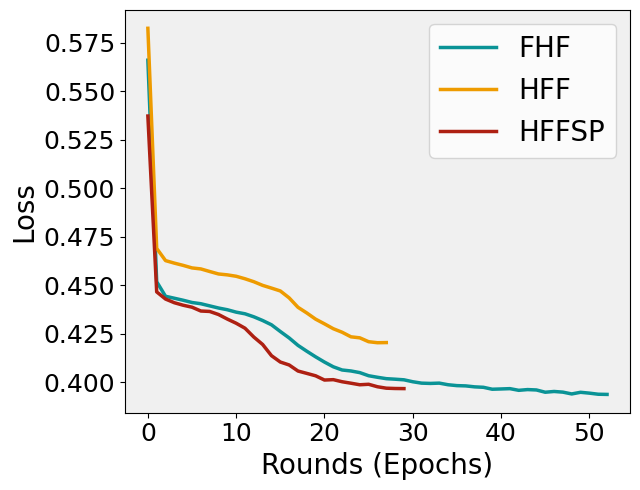

In [7]:
#['#0a9396', '#ee9b00', '#ae2012']
#plt.figure(facecolor='#f0f0f0')
plt.figure(figsize=(6.5, 5))
plt.gca().set_facecolor('#f0f0f0') 
plt.plot(FHF_logs['avg_normalised_loss'], label = "FHF", color = '#0a9396', linewidth = 2.5)
plt.plot(HF2_clogs['avg_normalised_loss'], label = "HFF", color = '#ee9b00', linewidth = 2.5)
plt.plot(HF2T_clogs['avg_normalised_loss'], label = "HFFSP", color = '#ae2012', linewidth = 2.5)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.xlabel("Rounds (Epochs)", fontsize = 20)
plt.ylabel("Loss", fontsize = 20)
plt.legend(fontsize = 20)
plt.tight_layout()
#plt.grid()
plt.savefig("loss_as_rounds(Adam).pdf")
plt.show()

# Time Costs

In [8]:
FHF_tc   = pd.read_csv("fh1_FHF_timing.csv")
HF2_tc   = pd.read_csv("fh1_V2HF2_nontrainable_timing.csv")
HF2T_tc  = pd.read_csv("fh1_V2HF2_trainable_timing.csv")

FHF_R   = len(FHF_logs)
HF2_R  = len(HF2_clogs)
HF2T_R = len(HF2T_clogs)
rounds = [FHF_R, HF2_R, HF2T_R]

FHF_tc.columns  = ['Methods', 'FHF']
HF2_tc.columns  = ['Methods', 'HFF']
HF2T_tc.columns = ['Methods', 'HFFSP']
col = list(FHF_tc['Methods'].values)

times = pd.concat([FHF_tc.T.iloc[1:,:],
           HF2_tc.T.iloc[1:,:],
           HF2T_tc.T.iloc[1:,:]])
times.columns = col
times.reset_index()
times['rounds'] = rounds
times

,setup_sec,data_preparation_sec,model_server_initialization_sec,fl_training_sec,residual_collection_sec,recon_matrix_sec,p2p_reconcile_sec,reconciliation_sec,evaluation_sec,total_sec,rounds
FHF,55.634257,55.556472,0.077783,12037.331597,103.203728,2.396567,18.689592,124.289886,6.862952,12224.118692,53
HFF,60.10162,60.077431,0.024189,5081.276677,109.292845,1.861088,18.248399,129.402332,8.357379,5279.138008,28
HFFSP,66.213961,66.188808,0.025153,7031.346245,109.937289,2.270542,18.252653,130.460485,7.62503,7235.645721,30


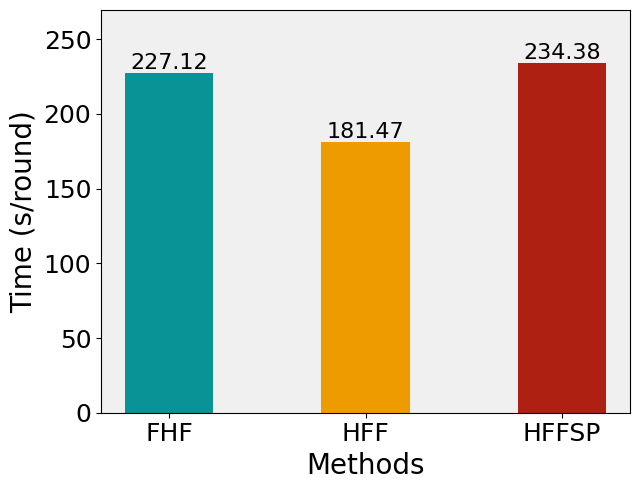

In [9]:
import matplotlib.pyplot as plt
import numpy as np

names = times['fl_training_sec'] / rounds
x = list(names.index)
y = (times['fl_training_sec'] / rounds).values
plt.figure(figsize=(6.5, 5))
plt.gca().set_facecolor('#f0f0f0')
bars = plt.bar(x, y, color= ['#0a9396', '#ee9b00', '#ae2012'], width=0.45)
# ['black', 'blue', 'red']


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=16, color='black' )

plt.ylim(0, max(y) * 1.15)
plt.ylabel('Time (s/round)', fontsize = 20)
plt.xlabel('Methods', fontsize = 20)
plt.yticks(fontsize = 18)
plt.xticks(fontsize = 18)
plt.tight_layout()
plt.savefig("times_per_round.pdf")
plt.show()


# MASE data for MCB tests 

In [10]:
FHF_mase   = pd.read_csv("fh1_FHF_per_node_metrics.csv")
HF2_mase   = pd.read_csv("fh1_V2HF2_nontrainable_per_node_metrics.csv")
HF2T_mase  = pd.read_csv("fh1_V2HF2_trainable_per_node_metrics.csv")

naive = pd.DataFrame()
naive['Naive'] = FHF_mase[FHF_mase['method'] == 'naive']['MASE'].reset_index(drop = True)
def metrics_collect(df_:pd.DataFrame, prefix: str, methods:list, metric = 'MASE'):
    df = pd.DataFrame()
    col = list(df_['method'].unique())
    col.remove('naive')
    len_ = len(col)
    for i in range(len_):
        df[prefix+methods[i]] = df_[df_['method'] == col[i]][metric].reset_index(drop=True)
    return df
methods = ['BASE', 'BU', 'MinTc', 'MinTs', 'OLS', 'WLSv', 'WLSs']
FHFmase = metrics_collect(df_ = FHF_mase, prefix = "FHF_", methods = methods)
HF2mase = metrics_collect(df_ = HF2_mase, prefix = "HFF_", methods = methods)
HF2Tmase = metrics_collect(df_ = HF2T_mase, prefix = "HFFSP_", methods = methods)

In [57]:
pd.concat([naive, FHFmase, HF2mase, HF2Tmase], axis =1).to_csv('all_per-node_mase.csv', index = False)
pd.concat([naive, FHFmase, HF2mase, HF2Tmase], axis =1)

,Naive,FHF_BASE,FHF_BU,FHF_MinTc,FHF_MinTs,FHF_OLS,FHF_WLSv,FHF_WLSs,HFF_BASE,HFF_BU,...,HFF_OLS,HFF_WLSv,HFF_WLSs,HFFSP_BASE,HFFSP_BU,HFFSP_MinTc,HFFSP_MinTs,HFFSP_OLS,HFFSP_WLSv,HFFSP_WLSs
0,1.267120,1.201587,1.239134,1.080595,1.090442,1.201059,1.210965,1.201059,1.301746,1.289323,...,1.300573,1.268736,1.300573,1.203020,1.249764,1.073732,1.079752,1.202548,1.218523,1.202548
1,0.905912,0.823357,0.823357,0.848200,0.842369,0.849493,0.823666,0.849493,0.832185,0.832185,...,0.846493,0.832274,0.846493,0.825524,0.825524,0.844101,0.840426,0.845580,0.825733,0.845580
2,1.152490,1.029002,1.029002,1.052443,1.041323,1.053394,1.030225,1.053394,1.048690,1.048690,...,1.061391,1.049151,1.061391,1.034142,1.034142,1.065370,1.051239,1.052840,1.035015,1.052840
3,1.421849,1.312162,1.302909,1.317306,1.312862,1.311164,1.303647,1.311164,1.322639,1.310110,...,1.318563,1.312862,1.318563,1.317947,1.304094,1.317617,1.313606,1.314658,1.307118,1.314658
4,0.924564,0.889287,0.889287,0.916560,0.909470,0.909954,0.889362,0.909954,0.894256,0.894256,...,0.906131,0.894199,0.906131,0.890251,0.890251,0.916058,0.907345,0.907111,0.890240,0.907111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.821559,0.997675,0.997675,1.040038,1.015394,1.015976,1.001094,1.015976,0.992294,0.992294,...,0.984803,0.987519,0.984803,0.998280,0.998280,1.048869,1.020977,1.000616,0.996146,1.000616
396,1.360264,1.187821,1.187821,1.234703,1.224985,1.196787,1.193903,1.196787,1.203302,1.203302,...,1.202686,1.202675,1.202686,1.194741,1.194741,1.239714,1.226593,1.198335,1.196888,1.198335
397,1.177806,1.076733,1.076733,1.094158,1.083743,1.077472,1.075857,1.077472,1.081373,1.081373,...,1.079230,1.079564,1.079230,1.078234,1.078234,1.093180,1.083396,1.076481,1.076575,1.076481
398,1.075168,1.065914,1.065914,1.113514,1.093326,1.098713,1.066136,1.098713,1.078945,1.078945,...,1.094361,1.078944,1.094361,1.066782,1.066782,1.119691,1.098753,1.088973,1.066847,1.088973


# RMSSE data for MCB tests

In [58]:
FHF_mase   = pd.read_csv("fh1_FHF_per_node_metrics.csv")
HF2_mase   = pd.read_csv("fh1_V2HF2_nontrainable_per_node_metrics.csv")
HF2T_mase  = pd.read_csv("fh1_V2HF2_trainable_per_node_metrics.csv")

naive_rmsse = pd.DataFrame()
naive_rmsse['Naive'] = FHF_mase[FHF_mase['method'] == 'naive']['RMSSE'].reset_index(drop = True)
def metrics_collect(df_:pd.DataFrame, prefix: str, methods:list, metric = 'MASE'):
    df = pd.DataFrame()
    col = list(df_['method'].unique())
    col.remove('naive')
    len_ = len(col)
    for i in range(len_):
        df[prefix+methods[i]] = df_[df_['method'] == col[i]][metric].reset_index(drop=True)
    return df
methods = ['BASE', 'BU', 'MinTc', 'MinTs', 'OLS', 'WLSv', 'WLSs']
FHFrmsse = metrics_collect(df_ = FHF_mase, prefix = "FHF_", methods = methods, metric = 'RMSSE')
HF2rmsse = metrics_collect(df_ = HF2_mase, prefix = "HFF_", methods = methods, metric = 'RMSSE')
HF2Trmsse = metrics_collect(df_ = HF2T_mase, prefix = "HFFSP_", methods = methods, metric = 'RMSSE')

In [61]:
pd.concat([naive_rmsse, FHFrmsse, HF2rmsse, HF2Trmsse], axis =1).to_csv('all_per-node_rmsse.csv', index = False)
pd.concat([naive_rmsse, FHFrmsse, HF2rmsse, HF2Trmsse], axis =1)

,Naive,FHF_BASE,FHF_BU,FHF_MinTc,FHF_MinTs,FHF_OLS,FHF_WLSv,FHF_WLSs,HFF_BASE,HFF_BU,...,HFF_OLS,HFF_WLSv,HFF_WLSs,HFFSP_BASE,HFFSP_BU,HFFSP_MinTc,HFFSP_MinTs,HFFSP_OLS,HFFSP_WLSv,HFFSP_WLSs
0,1.198684,1.108919,1.162723,0.971863,0.979960,1.108667,1.130655,1.108667,1.222282,1.209262,...,1.221373,1.192062,1.221373,1.127971,1.174078,0.974442,0.979509,1.127657,1.143556,1.127657
1,0.929270,0.804894,0.804894,0.807605,0.806277,0.808946,0.804864,0.808946,0.809294,0.809294,...,0.813442,0.809278,0.813442,0.805959,0.805959,0.808323,0.807092,0.809749,0.805936,0.809749
2,1.045621,0.877818,0.877818,0.886247,0.882208,0.879375,0.877821,0.879375,0.883541,0.883541,...,0.885845,0.883599,0.885845,0.881495,0.881495,0.890154,0.885963,0.882873,0.881497,0.882873
3,1.462194,1.323265,1.317725,1.316727,1.315522,1.318284,1.317807,1.318284,1.332038,1.321371,...,1.329055,1.324322,1.329055,1.326503,1.317426,1.314705,1.314980,1.321590,1.319273,1.321590
4,0.886104,0.804883,0.804883,0.808619,0.805073,0.808763,0.804808,0.808763,0.805525,0.805525,...,0.810659,0.805481,0.810659,0.805387,0.805387,0.810401,0.805968,0.809563,0.805326,0.809563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.984134,0.886979,0.886979,0.890284,0.884098,0.882000,0.883616,0.882000,0.886176,0.886176,...,0.881286,0.883135,0.881286,0.887112,0.887112,0.888476,0.882731,0.881508,0.883690,0.881508
396,1.217229,1.018859,1.018859,1.026091,1.021284,1.019109,1.019389,1.019109,1.028680,1.028680,...,1.027232,1.027235,1.027232,1.024925,1.024925,1.033539,1.028403,1.024822,1.025013,1.024822
397,1.201794,1.034508,1.034508,1.034084,1.028734,1.030036,1.031811,1.030036,1.036052,1.036052,...,1.034784,1.034796,1.034784,1.036275,1.036275,1.036419,1.031803,1.032903,1.034165,1.032903
398,1.024470,0.965820,0.965820,0.990600,0.977997,0.969577,0.965769,0.969577,0.969750,0.969750,...,0.975469,0.969730,0.975469,0.965574,0.965574,0.991903,0.979360,0.968004,0.965519,0.968004
